In [20]:
import numpy as np
from numpy import ndarray
from math import ceil
import dask.array as da
from dask.diagnostics import ProgressBar
from typing import Callable, Optional, Sequence, Tuple

from core.utils.helpers import normalize_data
from core.config.experiment import HessianConfig, EnhancementConfig, ProcessingConfig, MethodsConfig, SegmentationConfig
from core.io.logger import Logger, setup_logger
from core.pipeline.derivator import Derivator
from core.pipeline.enhancer import Enhancer 
from core.pipeline.segmenter import Segmenter

class Processor:
    
    def __init__(self, config: ProcessingConfig):
        self.use_gpu = config.use_gpu
        self.normalize = config.normalize
        self.parallelize = config.parallelize
        self.show_progress = config.show_progress
        self.overlap_size = config.overlap_size
        self.chunk_size = config.chunk_size
        
        self.derivator = Derivator(use_gpu=self.use_gpu)
        self.enhancer = Enhancer(use_gpu=self.use_gpu)
        self.segmenter = Segmenter()

    def enhance_data(self,
            data: ndarray,
            enhancement_function: Callable,
            enhancement_params: dict,
        ):
        
        # Parallel (3D)
        if self.parallelize and data.ndim == 3:
            chunk_size = self.chunk_size or tuple(ceil(s//2) for s in data.shape)
            overlap_size = self.overlap_size or max(enhancement_params.get('scales', [10]))
            
            # Parallelize 
            data_dask = da.from_array(data, chunks=chunk_size)

            processed_chunks = da.map_overlap(
                enhancement_function,
                data=data_dask,
                depth=overlap_size,
                boundary='reflect',
                dtype=np.float32,
                **enhancement_params,
            )

            if self.show_progress:
                with ProgressBar():
                    data_enhanced = processed_chunks.compute()
            else:
                data_enhanced = processed_chunks.compute()
                
        else: # Sequential (2D)
            data_enhanced = enhancement_function(data, **enhancement_params)
        
        # Normalization
        if self.normalize:
            data_enhanced = normalize_data(data_enhanced)
            
        return data_enhanced
        
    def process_data(self,
        data: ndarray,
        hessian_config: HessianConfig,
        enhancement_config: EnhancementConfig,
        segmentation_config: SegmentationConfig,
        methods: MethodsConfig,
        ground_truth: Optional[ndarray] = None,
    ) -> Tuple[ndarray, ndarray, float]:
        
        # Get functions
        hessian_function = self.derivator.select_hessian_function(methods.derivator)
        enhancement_function = self.enhancer.select_enhancement_function(methods.enhancer)
        segmentation_function = self.segmenter.select_segmentation_function(methods.segmenter)
        
        # Update configs
        hessian_params = hessian_config.to_dict()
        enhancement_config.hessian_function = hessian_function
        enhancement_config.hessian_params = hessian_params
        enhancement_params = enhancement_config.to_dict()
        segmentation_params = segmentation_config.to_dict()
        
        # Enhancement
        data_enhanced = self.enhance_data(
            data=data, 
            enhancement_function=enhancement_function, 
            enhancement_params=enhancement_params, 
            )
        
        # Segmentation
        data_segmented, threshold = segmentation_function(
            data=data_enhanced,
            ground_truth=ground_truth,
            **segmentation_params
        )

        return data_enhanced, data_segmented, threshold

    

In [22]:
processing_config = ProcessingConfig(
    use_gpu=False,
    normalize=True
)
derivator = Derivator(False)
enhancer = Enhancer(False)

hessian_config = HessianConfig(mode='reflect', cval=0.0)
enhancement_config = EnhancementConfig(
    scales=[2, 4, 6],
    alpha=0.5,
    beta=0.5,
    gamma=20,
    skimage=False,
)
segmentation_config = SegmentationConfig(None)
methods = MethodsConfig(
    derivator='farid',
    enhancer='frangi',
    segmenter='thresholding',
)

processor = Processor(processing_config)
data = np.zeros((20, 20))
ground_truth = np.zeros((20, 20))

enhanced, segmented, seuil = processor.process_data(data, hessian_config, enhancement_config, segmentation_config, methods, ground_truth)


c:\Users\noedo\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


In [ ]:
# enhancement_func = enhancer.select_enhancement_function(methods.enhancer)
# hessian_func = derivator.select_hessian_function(methods.derivator)

# processor.enhance_data(data, )


TypeError: 'tuple' object is not callable

---

In [13]:
shape_ = (2279, 1303, 912) 
print(shape_[0]/5)
print(shape_[1]/3)
print(shape_[2]/2)

455.8
434.3333333333333
456.0


In [ ]:
from core.io.loader import Loader
import os 
from pathlib import Path


loader = Loader("3d")

image = loader.load_data('data/3d/')

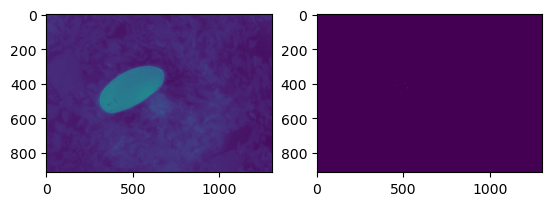

In [8]:
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.subplot(1, 2, 2)
plt.imshow(label)

In [ ]:
from core.pipeline.pipeline import Pipeline
from core.config.builder import ConfigBuilder
from core.config.setup import SetupConfig
from core.config.experiment import ExperimentConfig, LoadingConfig, MethodsConfig, EnhancementConfig, HessianConfig, SegmentationConfig, ProcessingConfig

pipeline = Pipeline(SetupConfig(
    name="pipeline",
    input_dir="test",
    output_dir="pipeline",
    log_file="pipline",
    debug_mode=False,
    plot_mode=False,
    save_mode=True,
)) 

loading_config = LoadingConfig(
    normalize=True,
    crop=False,
    target_shape=(32, 32, 32),
    raw_file="images/image_0.png",
    gt_file="labels/label_0.png",
)

methods_config = MethodsConfig(
    derivator="default",
    enhancer='frangi',
    segmenter='thresholding',
)

enhacement_config = EnhancementConfig(
    alpha=0.5,
    beta=0.5,
    gamma=10,
    scales=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    black_ridges=True,
    skimage=False,
)

processing_config = ProcessingConfig(
    normalize=True,
    parallelize=False,
    chunk_size=(32, 32, 32),
    overlap_size=10,
)

hessian_config = HessianConfig(
    mode='reflect',
    cval=0.0
)

segmentation_config = SegmentationConfig(
   threshold=None
)

experiment_config = ExperimentConfig(
    loading=loading_config,
    methods=methods_config,
    processing=processing_config,
    hessian=hessian_config,
    enhancement=enhacement_config,
    segmentation=segmentation_config,
)

14:34:06 - [INFO]: [INIT] Pipeline initialized


In [17]:
experiment = pipeline.run(config=experiment_config)

14:34:09 - [INFO]: [START] Pipeline execution
14:34:09 - [INFO]: [LOAD] Data image_0.png loaded | shape=(800, 800).
14:34:09 - [INFO]: [LOAD] Data label_0.png loaded | shape=(800, 800).
14:34:09 - [DEBUG]: [CALL] "enhance_data"
                       - args:   [<core.pipeline.enhancer.Enhancer object at 0x0000021996E5BB00>]
                       - kwargs: { data=ndarray(shape=(800, 800), dtype=float32), method='frangi', processing_params=ProcessingConfig(normalize=True, parallelize=False, chunk_size=(32, 32, 32), overlap_size=10), enhancement_params=EnhancementConfig(alpha=0.5, beta=0.5, gamma=10, scales=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10], scales_number=None, scales_range=None, black_ridges=True, hessian_function=<bound method Derivator.default of <core.pipeline.derivator.Derivator object at 0x0000021996E5B320>>, skimage=False), hessian_params=HessianConfig(mode='reflect', cval=0.0) }
14:34:09 - [INFO]: Sequential processing in progress...
14:34:09 - [DEBUG]: [CALL] "frangi"
            

In [13]:
from core.io.loader import Loader

loader = Loader("test")

image_raw = loader.load_data('images/image_0.png')
ground_truth = loader.load_data('labels/label_0.png')

In [ ]:
from core.loader import Loader
from src.pipeline import Pipeline
from core.config import SetupConfig
from src.enhancer import Enhancer

SetupConfig(
        name="test_benchmark",
        log_file="test",
        input_dir="data/test",
        output_dir=str("out"),
        debug_mode=True,
        plot_mode=True,
        save_mode=False,
    )

raw = Loader('data/test').load_data('test_raw.nii', crop=False)
enhanced = Enhancer().frangi(
    image=raw, 
    hessian_params={'mode': 'reflect','cval': 0,'use_gaussian_derivatives': True},
    skimage=True,
    scales=range(1, 10, 2)
)


12:34:32 - [INFO]: [LOAD] Data test_raw.nii loaded with shape (195, 155, 150) and normalized.
12:34:32 - [INFO]: The enhancement is done with frangi function from skimage.


12:42:42 - [INFO]: [LOAD] Data test_gt.nii loaded with shape (195, 155, 150) and normalized.


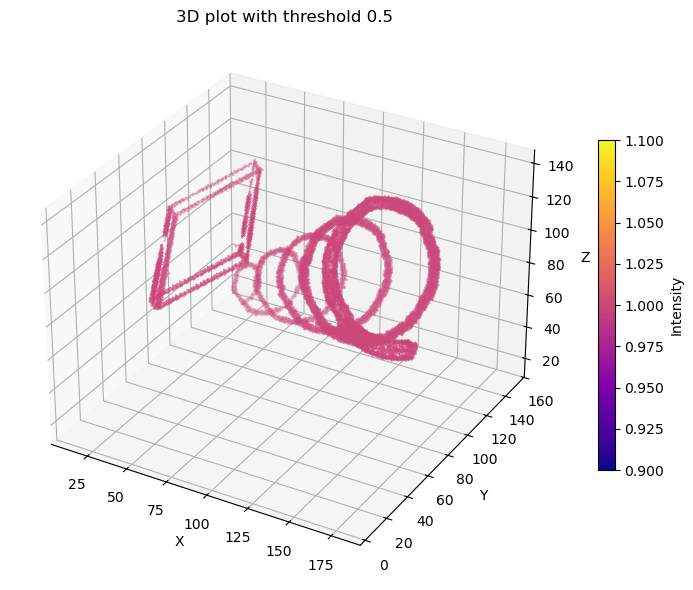

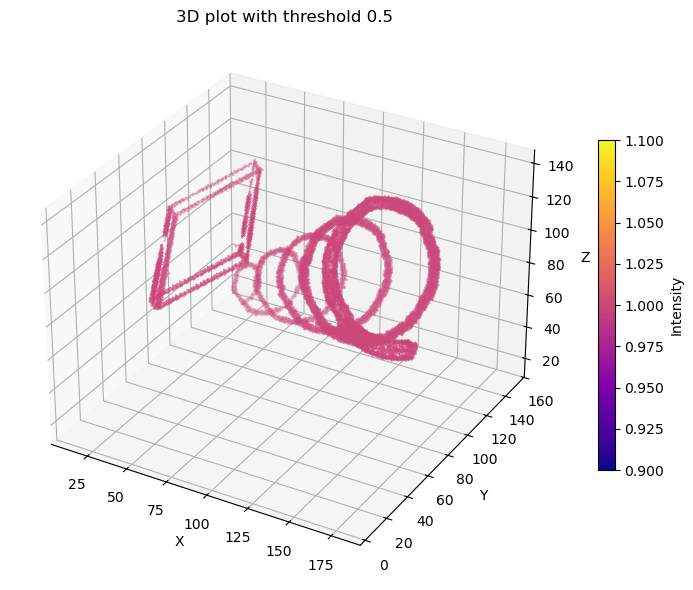

In [42]:
data = Loader('data/test').load_data('test_gt.nii', crop=False)
Viewer().display_volume(data, 0.5)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from benchmark.computational_time import scale_size_influence, volume_size_influence, chunk_number_influence

scale_size_influence(32, (1, 10), [2, 4], 'frangi', 2)
volume_size_influence(np.array([32, 64]), 2, (1, 10), 'frangi', 2)
chunk_number_influence([32, 64], 2, (1, 10), 'frangi', [2, 4])

[########################################] | 100% Completed | 2.18 sms
[########################################] | 100% Completed | 4.10 sms
08:35:38 - [INFO]: ======================================== RESUME ========================================

08:35:38 - [INFO]: 
Influence du nombre d'échelle sur le temps d'exécution du réhaussement

08:35:38 - [INFO]: Scales number:    [2, 4]
08:35:38 - [INFO]: Times sequential: [0.4265462999974261, 0.526276800002961]
08:35:38 - [INFO]: Times parallel:   [6.470020900000236, 4.167211899999529]
08:35:38 - [INFO]: 
|   Scales (num) |   Time sequential (s) |   Time parallel (s) |
|----------------|-----------------------|---------------------|
|              2 |                 0.427 |               6.470 |
|              4 |                 0.526 |               4.167 |
08:35:38 - [INFO]: ========================================================================================

[########################################] | 100% Completed | 2.52 sms


([32, 64],
 [2, 4],
 [[16, 8], [32, 16]],
 [[2.6615614000038477, 2.6376338000045507],
  [3.5068361000012374, 23.19713519999641]])